<a href="https://colab.research.google.com/github/msneha2812/Skillcraft-Task-1/blob/main/SkillCraft_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

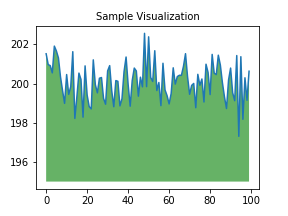

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

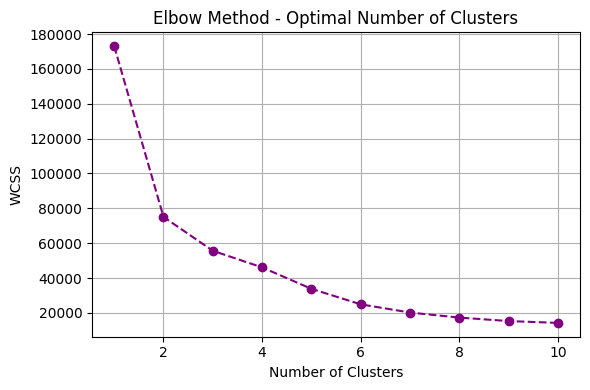

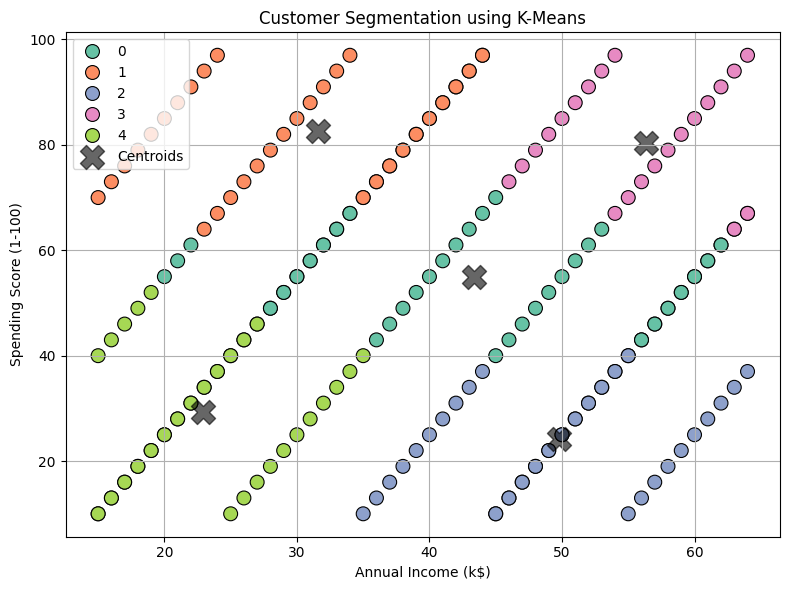

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

# Create mock Mall Customer Dataset
data = {
    'CustomerID': range(1, 201),
    'Gender': ['Male' if x % 2 == 0 else 'Female' for x in range(1, 201)],
    'Age': [18 + (x % 45) for x in range(200)],
    'Annual Income (k$)': [15 + (x % 50) for x in range(200)],
    'Spending Score (1-100)': [10 + (x * 3 % 90) for x in range(200)]
}

df = pd.DataFrame(data)

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Elbow method to find optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Elbow plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.tight_layout()
plt.show()

# Apply KMeans with optimal clusters (let’s assume k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add cluster to DataFrame
df['Cluster'] = y_kmeans

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='Set2',
    data=df, s=100, edgecolor='black'
)

# Plot centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=300, alpha=0.6, marker='X', label='Centroids')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
